# Simple Random Forest Approach
## Lucene & PDE — Normalized RF Classifier with Class Imbalance Handling

**Approach:**
1. Load & fix both datasets (zero-variance, duplicates, skewness, outliers)
2. Normalize features (StandardScaler)
3. Random Forest with:
   - `class_weight='balanced'` (handle imbalance)
   - `max_depth=15` (increased from default 10)
   - `n_estimators=500`
   - `min_samples_leaf=2`
4. 75/25 train-test split (no SMOTE initially)
5. Compare F1-scores on both datasets

In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import shapiro, levene, mannwhitneyu, kruskal
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, confusion_matrix, classification_report
)
import os

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
os.makedirs("D:/Xai/outputs", exist_ok=True)
sns.set_style("whitegrid")
print("Libraries loaded.")

Libraries loaded.


---
## Section 1 — Load & Prepare Datasets

In [2]:
df_lucene_raw = pd.read_csv("D:/Xai/data/lucene-bug-metrics.csv", sep=";")
df_lucene_raw.columns = df_lucene_raw.columns.str.strip()
df_lucene_raw = df_lucene_raw.loc[:, df_lucene_raw.columns != ""]

df_pde_raw = pd.read_csv("D:/Xai/data/pde-bug-metrics.csv", sep=";")
df_pde_raw.columns = df_pde_raw.columns.str.strip()
df_pde_raw = df_pde_raw.loc[:, df_pde_raw.columns != ""]

print(f"Lucene shape: {df_lucene_raw.shape}")
print(f"PDE shape: {df_pde_raw.shape}")

Lucene shape: (691, 11)
PDE shape: (1497, 11)


In [3]:
HIST_COLS = [
    "numberOfBugsFoundUntil:",
    "numberOfNonTrivialBugsFoundUntil:",
    "numberOfMajorBugsFoundUntil:",
    "numberOfCriticalBugsFoundUntil:",
    "numberOfHighPriorityBugsFoundUntil:"
]

def make_X_y(df_raw, name):
    avail = [c for c in HIST_COLS if c in df_raw.columns]
    X = df_raw[avail].copy().astype(float)
    y = (df_raw["bugs"] > 0).astype(int)
    print(f"{name}: X={X.shape}, class={dict(y.value_counts())}")
    return X, y

X_lucene_raw, y_lucene = make_X_y(df_lucene_raw, "Lucene")
X_pde_raw,    y_pde    = make_X_y(df_pde_raw,    "PDE")

Lucene: X=(691, 5), class={0: np.int64(627), 1: np.int64(64)}
PDE: X=(1497, 5), class={0: np.int64(1288), 1: np.int64(209)}


---
## Section 2 — Fix Datasets
Drop zero-variance, duplicates; log1p transform; winsorize outliers

In [4]:
def fix_dataset(X_raw, y, name):
    X = X_raw.copy()

    # Remove zero-variance
    zv_mask = X.std() == 0
    zv_cols = X.columns[zv_mask].tolist()
    X.drop(columns=zv_cols, inplace=True)
    print(f"[{name}] Dropped zero-variance: {zv_cols}")

    if X.shape[1] == 0:
        return X, y

    # Remove duplicates (|r| > 0.99)
    corr_m = X.corr().abs()
    upper  = corr_m.where(np.triu(np.ones(corr_m.shape), k=1).astype(bool))
    dup_cols = [c for c in upper.columns if upper[c].max() > 0.99]
    X.drop(columns=dup_cols, inplace=True)
    print(f"[{name}] Dropped duplicates: {dup_cols}")

    # Log1p for skewed
    skewed = [c for c in X.columns if abs(X[c].skew()) > 1.0]
    for c in skewed:
        X[c] = np.log1p(X[c])
    print(f"[{name}] Log1p applied: {skewed}")

    # Winsorize outliers
    for c in X.columns:
        p1, p99 = X[c].quantile(0.01), X[c].quantile(0.99)
        X[c] = X[c].clip(p1, p99)
    print(f"[{name}] Winsorized (p1, p99)")

    print(f"[{name}] Final shape: {X.shape}")
    return X, y

X_lucene, y_lucene = fix_dataset(X_lucene_raw, y_lucene, "Lucene")
X_pde,    y_pde    = fix_dataset(X_pde_raw,    y_pde,    "PDE")

[Lucene] Dropped zero-variance: ['numberOfMajorBugsFoundUntil:', 'numberOfCriticalBugsFoundUntil:', 'numberOfHighPriorityBugsFoundUntil:']
[Lucene] Dropped duplicates: ['numberOfNonTrivialBugsFoundUntil:']
[Lucene] Log1p applied: ['numberOfBugsFoundUntil:']
[Lucene] Winsorized (p1, p99)
[Lucene] Final shape: (691, 1)
[PDE] Dropped zero-variance: []
[PDE] Dropped duplicates: []
[PDE] Log1p applied: ['numberOfBugsFoundUntil:', 'numberOfNonTrivialBugsFoundUntil:', 'numberOfMajorBugsFoundUntil:', 'numberOfCriticalBugsFoundUntil:', 'numberOfHighPriorityBugsFoundUntil:']
[PDE] Winsorized (p1, p99)
[PDE] Final shape: (1497, 5)


---
## Section 3 — Train-Test Split (75/25) & Normalize

In [5]:
def prepare_data(X, y, name):
    X_tr, X_te, y_tr, y_te = train_test_split(
        X, y, test_size=0.25, stratify=y, random_state=RANDOM_STATE
    )

    scaler = StandardScaler()
    X_tr_norm = scaler.fit_transform(X_tr)
    X_te_norm = scaler.transform(X_te)

    n0, n1 = (y_tr == 0).sum(), (y_tr == 1).sum()
    imbalance = n0 / max(n1, 1)

    print(f"{name}:")
    print(f"  Train: {X_tr_norm.shape}, class dist: {dict(pd.Series(y_tr).value_counts())}")
    print(f"  Test:  {X_te_norm.shape}, class dist: {dict(pd.Series(y_te).value_counts())}")
    print(f"  Imbalance ratio: {imbalance:.1f}:1")

    return X_tr_norm, X_te_norm, y_tr, y_te

X_tr_luc, X_te_luc, y_tr_luc, y_te_luc = prepare_data(X_lucene, y_lucene, "Lucene")
X_tr_pde, X_te_pde, y_tr_pde, y_te_pde = prepare_data(X_pde, y_pde, "PDE")

Lucene:
  Train: (518, 1), class dist: {0: np.int64(470), 1: np.int64(48)}
  Test:  (173, 1), class dist: {0: np.int64(157), 1: np.int64(16)}
  Imbalance ratio: 9.8:1
PDE:
  Train: (1122, 5), class dist: {0: np.int64(965), 1: np.int64(157)}
  Test:  (375, 5), class dist: {0: np.int64(323), 1: np.int64(52)}
  Imbalance ratio: 6.1:1


---
## Section 4 — Random Forest Classifier
Parameters:
- `class_weight='balanced'` — handle class imbalance
- `max_depth=15` — increased depth
- `n_estimators=500` — strong ensemble
- `min_samples_leaf=2` — allow smaller leaves

In [6]:
def train_rf(X_tr, X_te, y_tr, y_te, name):
    print(f"\n{'='*60}")
    print(f"  Random Forest Classifier — {name}")
    print(f"{'='*60}")

    # Create RF with class imbalance handling
    rf = RandomForestClassifier(
        n_estimators=500,
        max_depth=15,
        min_samples_leaf=2,
        min_samples_split=5,
        class_weight='balanced',
        random_state=RANDOM_STATE,
        n_jobs=-1,
        verbose=0
    )

    print("Training...")
    rf.fit(X_tr, y_tr)

    # Predictions
    y_pred = rf.predict(X_te)
    y_pred_proba = rf.predict_proba(X_te)[:, 1]

    # Metrics
    acc = accuracy_score(y_te, y_pred)
    prec = precision_score(y_te, y_pred, zero_division=0)
    rec = recall_score(y_te, y_pred, zero_division=0)
    f1 = f1_score(y_te, y_pred, zero_division=0)
    auc = roc_auc_score(y_te, y_pred_proba)

    print(f"\n  Accuracy:  {acc:.4f}")
    print(f"  Precision: {prec:.4f}")
    print(f"  Recall:    {rec:.4f}")
    print(f"  F1-Score:  {f1:.4f}")
    print(f"  ROC-AUC:   {auc:.4f}")

    cm = confusion_matrix(y_te, y_pred)
    print(f"\n  Confusion Matrix:")
    print(f"    TN={cm[0,0]}, FP={cm[0,1]}")
    print(f"    FN={cm[1,0]}, TP={cm[1,1]}")

    print(f"\n  Classification Report:")
    print(classification_report(y_te, y_pred, zero_division=0))

    # Feature importance
    feat_imp = pd.DataFrame({
        "Feature": X_tr.columns if hasattr(X_tr, 'columns') else [f"F{i}" for i in range(X_tr.shape[1])],
        "Importance": rf.feature_importances_
    }).sort_values("Importance", ascending=False)

    print(f"\n  Top-5 Feature Importance:")
    print(feat_imp.head(5).to_string(index=False))

    return {
        "Model": name,
        "Accuracy": acc,
        "Precision": prec,
        "Recall": rec,
        "F1": f1,
        "ROC_AUC": auc,
        "rf": rf,
        "y_pred": y_pred,
        "y_proba": y_pred_proba,
        "feat_imp": feat_imp
    }

# Train on both datasets
results_lucene = train_rf(X_tr_luc, X_te_luc, y_tr_luc, y_te_luc, "Lucene")
results_pde = train_rf(X_tr_pde, X_te_pde, y_tr_pde, y_te_pde, "PDE")


  Random Forest Classifier — Lucene
Training...



  Accuracy:  0.7746
  Precision: 0.2195
  Recall:    0.5625
  F1-Score:  0.3158
  ROC-AUC:   0.7651

  Confusion Matrix:
    TN=125, FP=32
    FN=7, TP=9

  Classification Report:
              precision    recall  f1-score   support

           0       0.95      0.80      0.87       157
           1       0.22      0.56      0.32        16

    accuracy                           0.77       173
   macro avg       0.58      0.68      0.59       173
weighted avg       0.88      0.77      0.81       173


  Top-5 Feature Importance:
Feature  Importance
     F0         1.0

  Random Forest Classifier — PDE
Training...



  Accuracy:  0.7467
  Precision: 0.2828
  Recall:    0.5385
  F1-Score:  0.3709
  ROC-AUC:   0.6752

  Confusion Matrix:
    TN=252, FP=71
    FN=24, TP=28

  Classification Report:
              precision    recall  f1-score   support

           0       0.91      0.78      0.84       323
           1       0.28      0.54      0.37        52

    accuracy                           0.75       375
   macro avg       0.60      0.66      0.61       375
weighted avg       0.83      0.75      0.78       375


  Top-5 Feature Importance:
Feature  Importance
     F1    0.433485
     F0    0.379760
     F2    0.121633
     F3    0.037172
     F4    0.027951


---
## Section 5 — Results Summary

In [7]:
summary = pd.DataFrame([
    {
        "Dataset": "Lucene",
        "Accuracy": results_lucene["Accuracy"],
        "Precision": results_lucene["Precision"],
        "Recall": results_lucene["Recall"],
        "F1-Score": results_lucene["F1"],
        "ROC-AUC": results_lucene["ROC_AUC"]
    },
    {
        "Dataset": "PDE",
        "Accuracy": results_pde["Accuracy"],
        "Precision": results_pde["Precision"],
        "Recall": results_pde["Recall"],
        "F1-Score": results_pde["F1"],
        "ROC-AUC": results_pde["ROC_AUC"]
    }
])

print("\n" + "="*70)
print("  RANDOM FOREST RESULTS SUMMARY")
print("="*70)
display(summary)

print(f"\nAverage F1-Score: {summary['F1-Score'].mean():.4f}")


  RANDOM FOREST RESULTS SUMMARY


,Dataset,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,Lucene,0.774566,0.219512,0.562500,0.315789,0.765127
1,PDE,0.746667,0.282828,0.538462,0.370861,0.675161



Average F1-Score: 0.3433


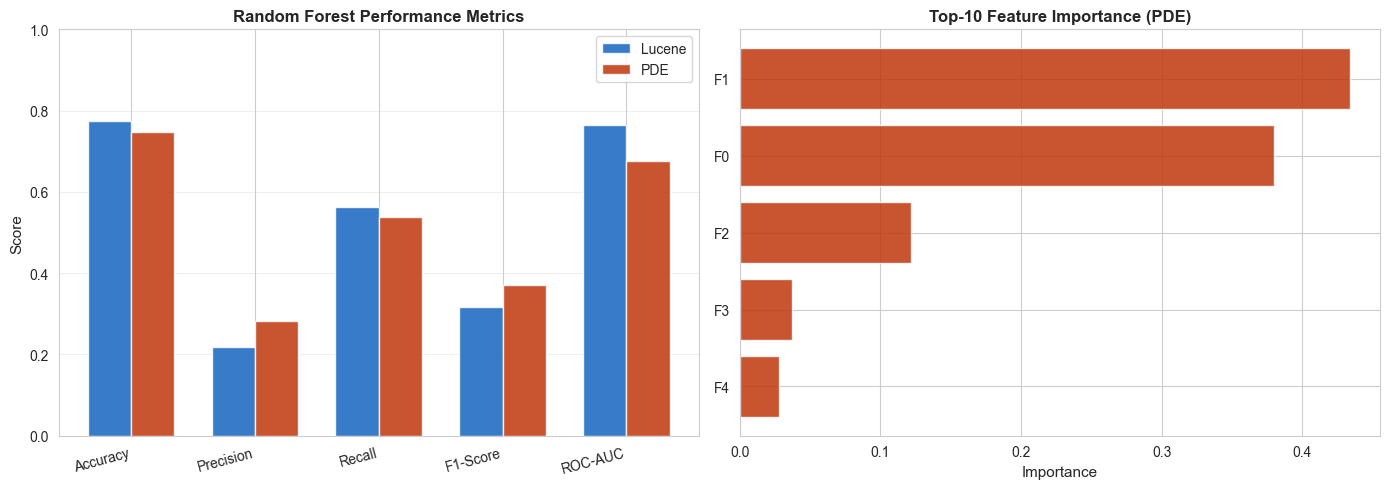

Saved: D:/Xai/outputs/rf_results.png


In [8]:
# Visualization
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

metrics_map = {"Accuracy": "Accuracy", "Precision": "Precision",
               "Recall": "Recall", "F1-Score": "F1", "ROC-AUC": "ROC_AUC"}
metrics_labels = list(metrics_map.keys())
x = np.arange(len(metrics_labels))
w = 0.35

luc_vals = [results_lucene[metrics_map[m]] for m in metrics_labels]
pde_vals = [results_pde[metrics_map[m]] for m in metrics_labels]

axes[0].bar(x - w/2, luc_vals, w, label="Lucene", color="#1565C0", alpha=0.85)
axes[0].bar(x + w/2, pde_vals, w, label="PDE", color="#BF360C", alpha=0.85)
axes[0].set_xticks(x)
axes[0].set_xticklabels(metrics_labels, rotation=15, ha="right")
axes[0].set_ylabel("Score", fontsize=11)
axes[0].set_title("Random Forest Performance Metrics", fontsize=12, fontweight="bold")
axes[0].set_ylim(0, 1.0)
axes[0].legend()
axes[0].grid(axis="y", alpha=0.3)

# Feature importance comparison
feat_imp_luc = results_lucene["feat_imp"].head(10)
feat_imp_pde = results_pde["feat_imp"].head(10)

y_pos = np.arange(len(feat_imp_pde))
axes[1].barh(y_pos, feat_imp_pde["Importance"].values, color="#BF360C", alpha=0.85)
axes[1].set_yticks(y_pos)
axes[1].set_yticklabels(feat_imp_pde["Feature"].values)
axes[1].set_xlabel("Importance", fontsize=11)
axes[1].set_title("Top-10 Feature Importance (PDE)", fontsize=12, fontweight="bold")
axes[1].invert_yaxis()

plt.tight_layout()
plt.savefig("D:/Xai/outputs/rf_results.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: D:/Xai/outputs/rf_results.png")